In [2]:
import os
import sys
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# Модели и метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.linear_model import Lasso, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    HistGradientBoostingRegressor, 
    StackingRegressor
)

current_path = Path(os.getcwd())
PROJECT_ROOT = current_path.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Локальные модули проекта ---
import src
from src import core, viz
from src.config import *
from src.pipeline import get_pipeline
from src.transformers import *

# --- Конфигурация отображения и отладки ---
%load_ext autoreload
%autoreload 2

sns.set_theme(style="whitegrid")
RANDOM_STATE = RANDOM_STATE  # Глобальный сид для воспроизводимости

In [2]:
# 1. Загружаем сырые данные
train_raw = pd.read_csv(TRAIN_DATA)
test_raw = pd.read_csv(TEST_DATA)

mask = (train_raw['SalePrice'] < 250000) & (train_raw['OverallQual'] == 10)

# Берем ID из этих строк 
outlier_ids = train_raw.loc[mask, 'Id'].tolist()
train_clean = core.clean_outliers(train_raw, outlier_ids)

# 2. Разделяем на X и y
X_train = train_clean.drop([TARGET, 'Id'], errors='ignore', axis=1)
y_train = core.log_transform_target(train_clean[TARGET])# Обязательно логарифмируем таргет!

X_test = test_raw.drop(columns=['Id'], errors='ignore')
# 3. Загружаем и применяем Pipeline
pipeline = joblib.load(os.path.join(FEATURE_ENG_DIR, 'final_pipeline.joblib'))
X_prepared = pipeline.fit_transform(X_train)
test_prepared = pipeline.transform(X_test)
print(f"Размерность данных после Pipeline: {X_prepared.shape}, {y_train.shape}")
print(f"Осталось пропусков в тесте: {np.isnan(test_prepared).sum().sum()}")

Размерность данных после Pipeline: (1458, 264), (1458,)
Осталось пропусков в тесте: 0


In [3]:
X_prepared

array([[ 1.06110904, -0.23828489,  0.58632935, ...,  1.27032643,
        -0.3035372 , -0.346144  ],
       [-0.68900067, -0.23828489,  0.58632935, ..., -0.76015847,
        -0.3035372 , -0.346144  ],
       [ 1.06110904, -0.23828489,  0.58632935, ...,  0.52711738,
        -0.3035372 , -0.346144  ],
       ...,
       [ 2.81121875,  2.60941482, -0.55654256, ..., -0.76015847,
        -0.3035372 , -0.346144  ],
       [-0.68900067, -0.23828489, -0.55654256, ..., -0.21609168,
        -0.3035372 , -0.346144  ],
       [ 1.06110904, -0.23828489, -0.55654256, ..., -0.95930074,
        -0.3035372 , -0.346144  ]], shape=(1458, 264))

In [4]:
train_clean[(train_clean['SalePrice'] < 250000) & (train_clean['OverallQual'] == 10)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [ ]:
# 1. Строим Baseline модель
dummy_regr = DummyRegressor(strategy="mean")
cv = KFold(random_state=RANDOM_STATE, shuffle=True, n_splits=5)
# 2. Прогоняем через кросс-валидацию (те же 5 фолдов)
cv_results_dummy = cross_validate(
    dummy_regr, 
    X_prepared, 
    y_train, 
    cv=cv, 
    scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
)

# 3. Переводим результаты в читаемый вид
dummy_rmse = np.sqrt(-cv_results_dummy['test_neg_mean_squared_error'].mean())
dummy_mae = -cv_results_dummy['test_neg_mean_absolute_error'].mean()
dummy_mse = -cv_results_dummy['test_neg_mean_squared_error'].mean()
dummy_r2 = cv_results_dummy['test_r2'].mean()

core.print_cv_results(cv_results_dummy, 'cv_results_dummy')# Покажет 0, тк в данном случае MSE это дисперсия

--- РЕЗУЛЬТАТЫ cv_results_dummy ---
Честный RMSE на CV: 0.3996
Честный MSE на CV:  0.1597
Честный r2 на CV:   -0.0007
Честный MAE на CV:  0.3102


In [ ]:

lasso_model = Lasso(max_iter=10000, random_state=RANDOM_STATE, selection='random')

param_grid = {
    'alpha' : np.logspace(-4, 1, 100)
}

scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

grid_search_lasso = core.run_search(lasso_model, param_grid, cv, scoring, X_prepared, y_train)

best_rmse_lasso = np.sqrt(-grid_search_lasso.best_score_)
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
best_index_lasso = grid_search_lasso.best_index_

core.print_grid_search_results(grid_search_lasso, model_name="Lasso")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- РЕЗУЛЬТАТЫ Lasso ---
Честный MSE на валидации (CV):  0.0139
Честный RMSE на валидации (CV): 0.1179
Честный r2 на валидации (CV):   0.9126
Честный MAE на валидации (CV):  0.0823
Лучшие параметры: {'alpha': np.float64(0.0036783797718286343)}


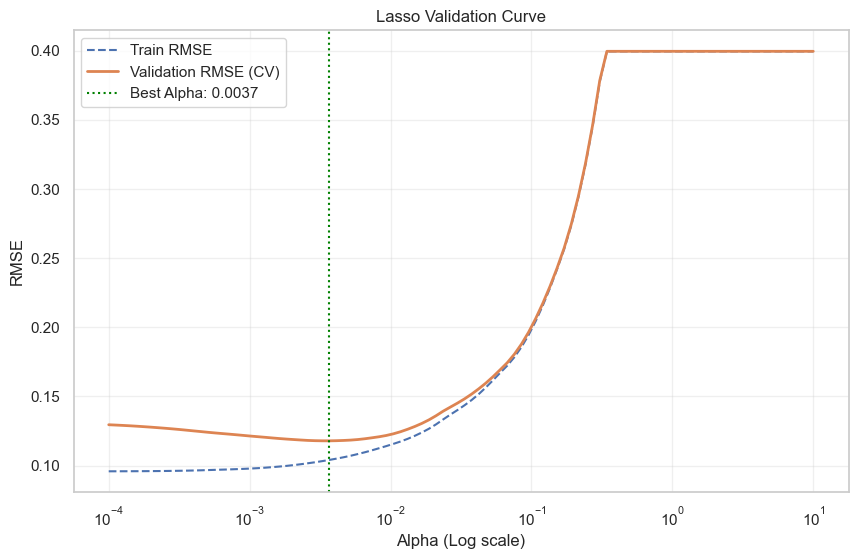

In [7]:
viz.plot_lasso_cv_results(
    grid_search_lasso.cv_results_, 
    param_grid['alpha'], 
    best_alpha_lasso
)

Lasso занулила 168 признаков из 264.
График сохранен по пути: C:\Users\ggosh\AI_Work\MLtask\MLtask\project\artifacts\03_modeling_eval\figures\linearity_importace.png


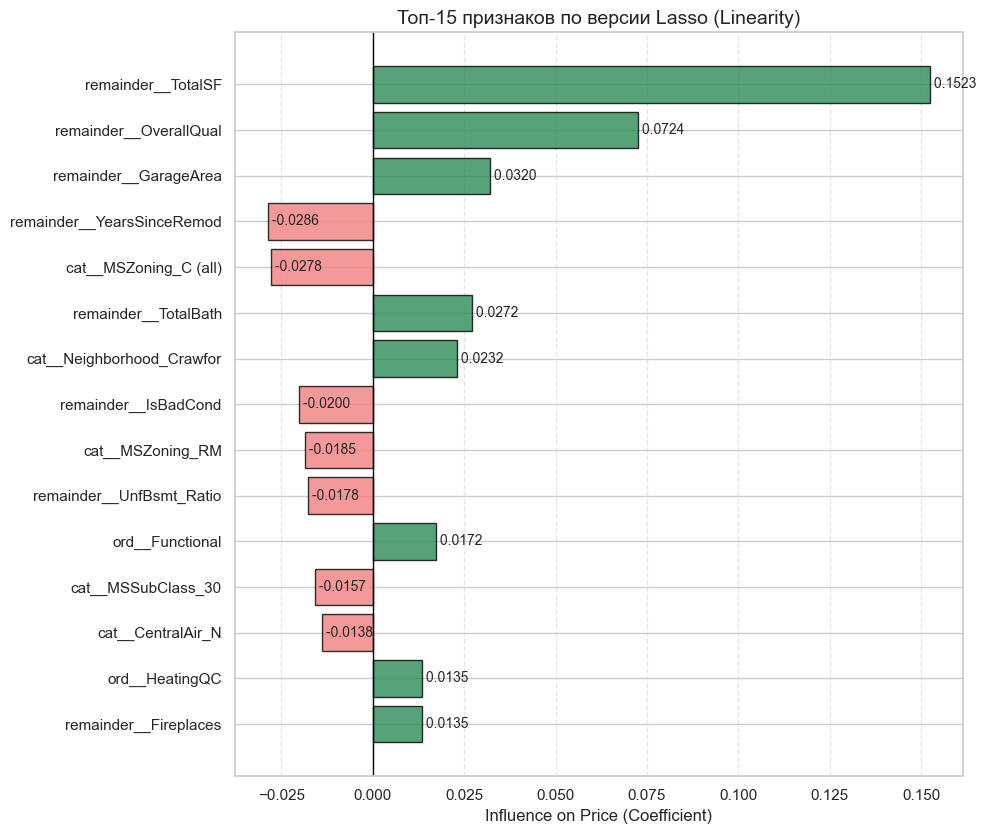

In [ ]:
best_lasso = grid_search_lasso.best_estimator_

feature_names = pipeline.get_feature_names_out() 

viz.plot_lasso_coefficients(
    model=best_lasso, 
    feature_names=feature_names, 
    top_n=15,
    title='Топ-15 признаков по версии Lasso (Linearity)',
    save_path=os.path.join(MODELING_FIGURES_DIR, 'linearity_importace.png')
)

In [9]:
# Возвращаемся из логарифмов в доллары
y_cv_preds_log = cross_val_predict(grid_search_lasso.best_estimator_, X_prepared, y_train, cv=cv)
y_true_dollars = np.expm1(y_train)
y_cv_preds_dollars = np.expm1(y_cv_preds_log)
final_mae_dollars = mean_absolute_error(y_true_dollars, y_cv_preds_dollars)

print(f"--- ЧЕСТНАЯ ПРОВЕРКА (Кросс-валидация) ---")
print(f"честная MAE: ${final_mae_dollars:,.0f}")

train_mae_dollars = mean_absolute_error(y_true_dollars, np.expm1(grid_search_lasso.best_estimator_.predict(X_prepared)))
print(f"Оптимистичная ошибка на трейне: ${train_mae_dollars:,.0f}")
print(f"Разница: ${final_mae_dollars - train_mae_dollars:,.0f}")

--- ЧЕСТНАЯ ПРОВЕРКА (Кросс-валидация) ---
честная MAE: $14,347
Оптимистичная ошибка на трейне: $13,104
Разница: $1,244


In [ ]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, bootstrap=True, oob_score=True)

rf_grid = {
    'n_estimators' : [100, 300],
    'min_samples_leaf' : [1,5],
    'max_depth' : [None, 10, 20],
    'ccp_alpha': [0.0, 0.01, 0.1],
    'max_features': ['sqrt', 0.3],
    'max_leaf_nodes' : [None, 100, 150]
}

grid_search_rf = core.run_search(estimator=rf, param_grid=rf_grid, cv=cv, scoring=scoring, X_train=X_prepared, y_train=y_train)
best_rmse_rf = np.sqrt(-grid_search_rf.best_score_)
best_index_rf = grid_search_rf.best_index_
core.print_grid_search_results(grid_search_rf, model_name="RandomForestRegressor")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
--- РЕЗУЛЬТАТЫ RandomForestRegressor ---
Честный MSE на валидации (CV):  0.0174
Честный RMSE на валидации (CV): 0.1320
Честный r2 на валидации (CV):   0.8907
Честный MAE на валидации (CV):  0.0904
Лучшие параметры: {'ccp_alpha': 0.0, 'max_depth': 20, 'max_features': 0.3, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'n_estimators': 300}


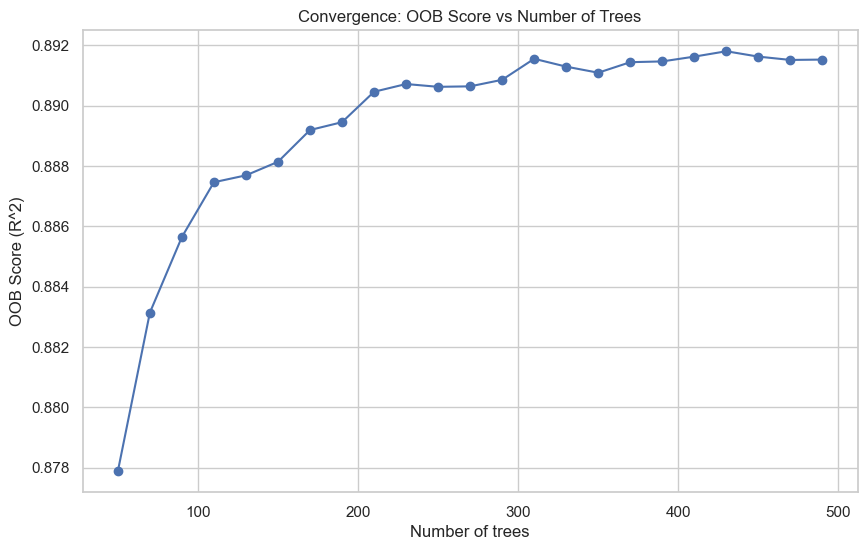

In [28]:
viz.plot_rf_convergence(
    grid_search_rf.best_params_, 
    X_prepared, 
    y_train, 
    save_path=os.path.join(MODELING_FIGURES_DIR, 'oob_score_RF.png')
)

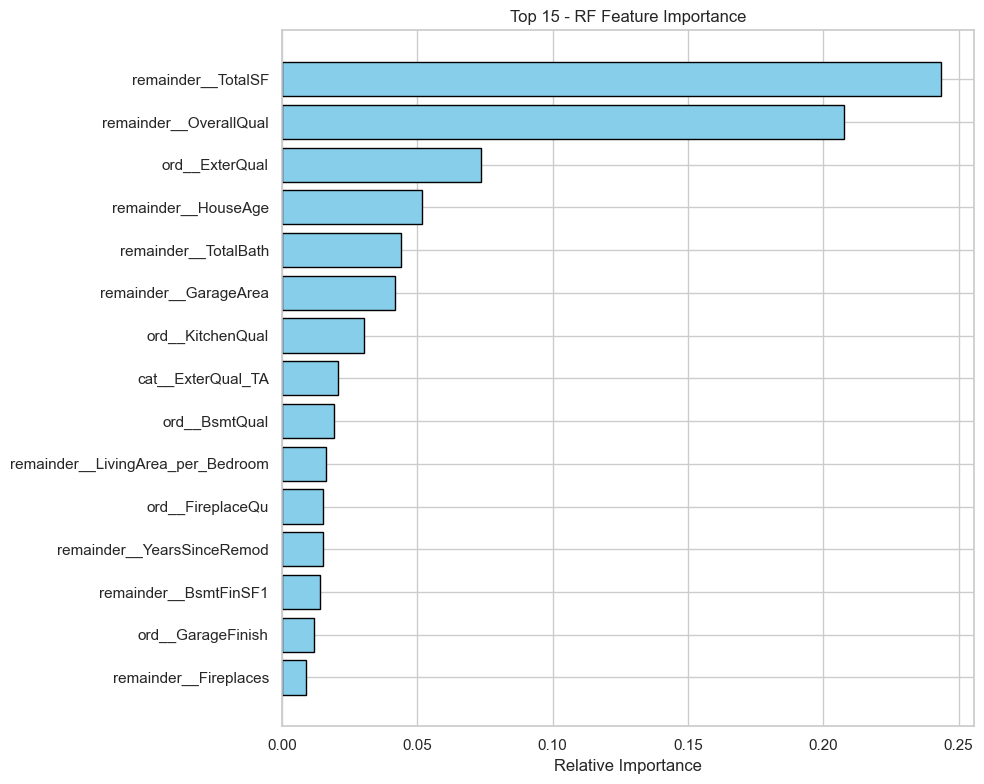

In [29]:
viz.plot_feature_importance(
    grid_search_rf.best_estimator_, 
    feature_names, 
    title="Top 15 - RF Feature Importance",
    save_path=os.path.join(MODELING_FIGURES_DIR, 'feature_importance_RF.png')
)

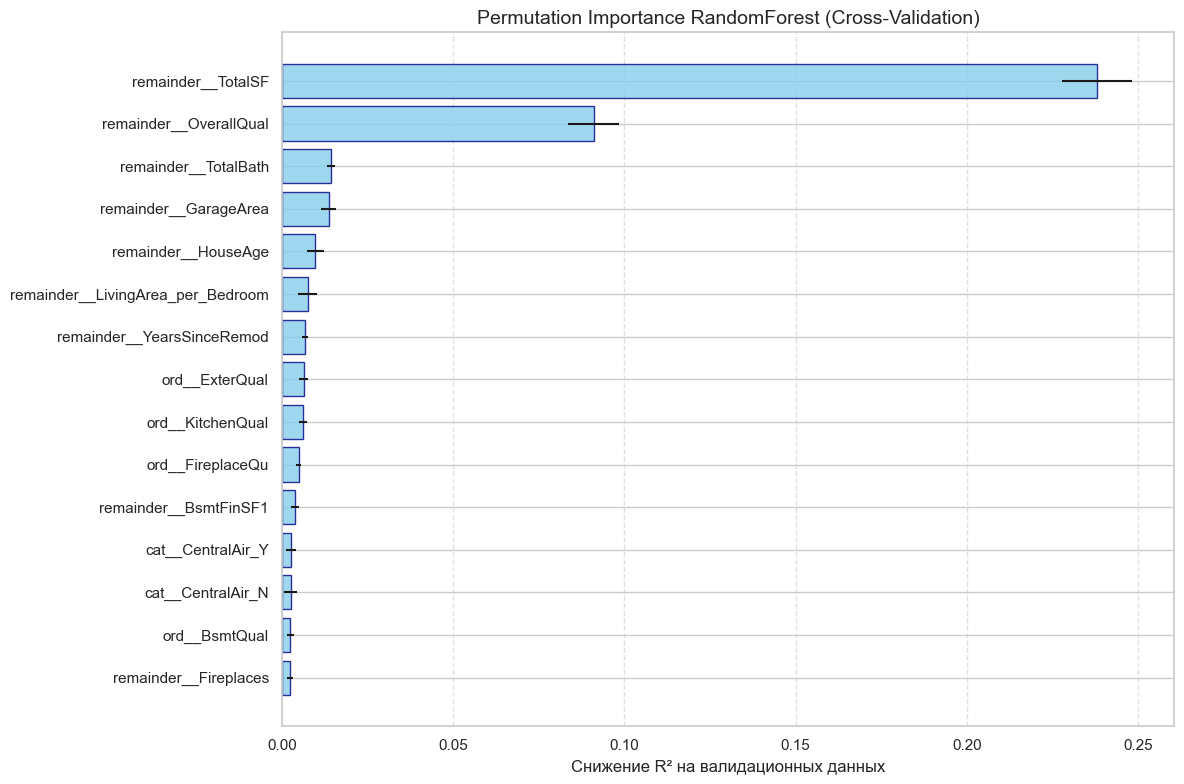

In [ ]:
mean_imp, std_imp = core.calculate_cv_permutation_importance(
    grid_search_rf.best_estimator_, X_prepared, y_train, cv
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_imp,
    'std': std_imp
}).sort_values(by='importance', ascending=False).head(15) # Топ-15

viz.plot_permutation_importance(importance_df, model_name="RandomForest", save_path = os.path.join(MODELING_FIGURES_DIR, 'permutation_importance_RF.png'))

In [14]:
hgbr = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=20, validation_fraction=0.1)
hgbr_grid = {
    'max_iter': [2000],
    'learning_rate': [0.03, 0.05, 0.1], 
    'max_leaf_nodes': [2, 3, 4], 
    'min_samples_leaf': [2, 3, 5, 7], 
    'l2_regularization': [5.0, 10.0, 20.0, 40.0]
}

grid_search_hgbr = core.run_search(
    estimator=hgbr, 
    param_grid=hgbr_grid, 
    cv=cv, 
    scoring=scoring, 
    X_train=X_prepared, 
    y_train=y_train
)
core.print_grid_search_results(grid_search_hgbr, model_name="HistGradientBoosting")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
--- РЕЗУЛЬТАТЫ HistGradientBoosting ---
Честный MSE на валидации (CV):  0.0160
Честный RMSE на валидации (CV): 0.1265
Честный r2 на валидации (CV):   0.8996
Честный MAE на валидации (CV):  0.0887
Лучшие параметры: {'l2_regularization': 10.0, 'learning_rate': 0.03, 'max_iter': 2000, 'max_leaf_nodes': 3, 'min_samples_leaf': 5}


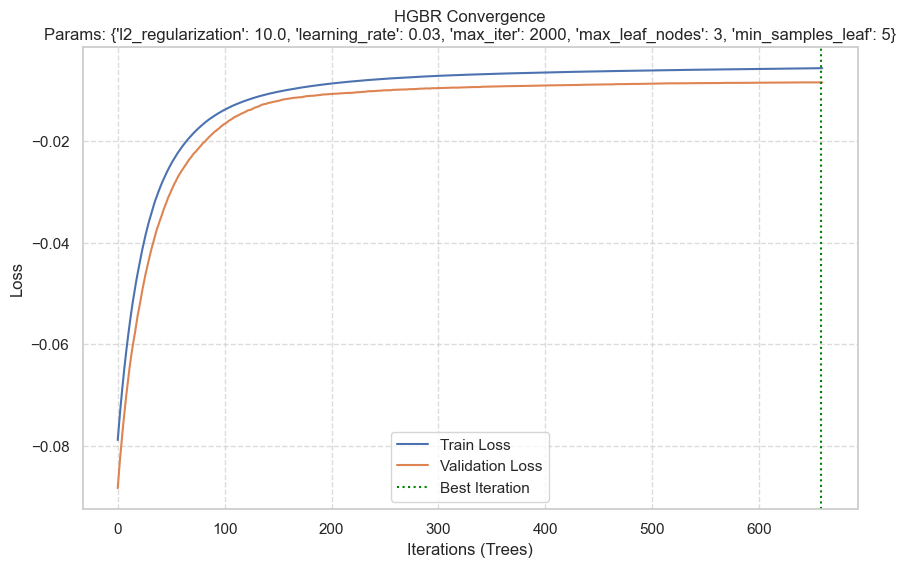

In [15]:
viz.plot_hgbr_learning_curve(
    grid_search_hgbr.best_estimator_, 
    grid_search_hgbr.best_params_,
    save_path=os.path.join(MODELING_FIGURES_DIR, 'hgbr_learning_curve.png')
)

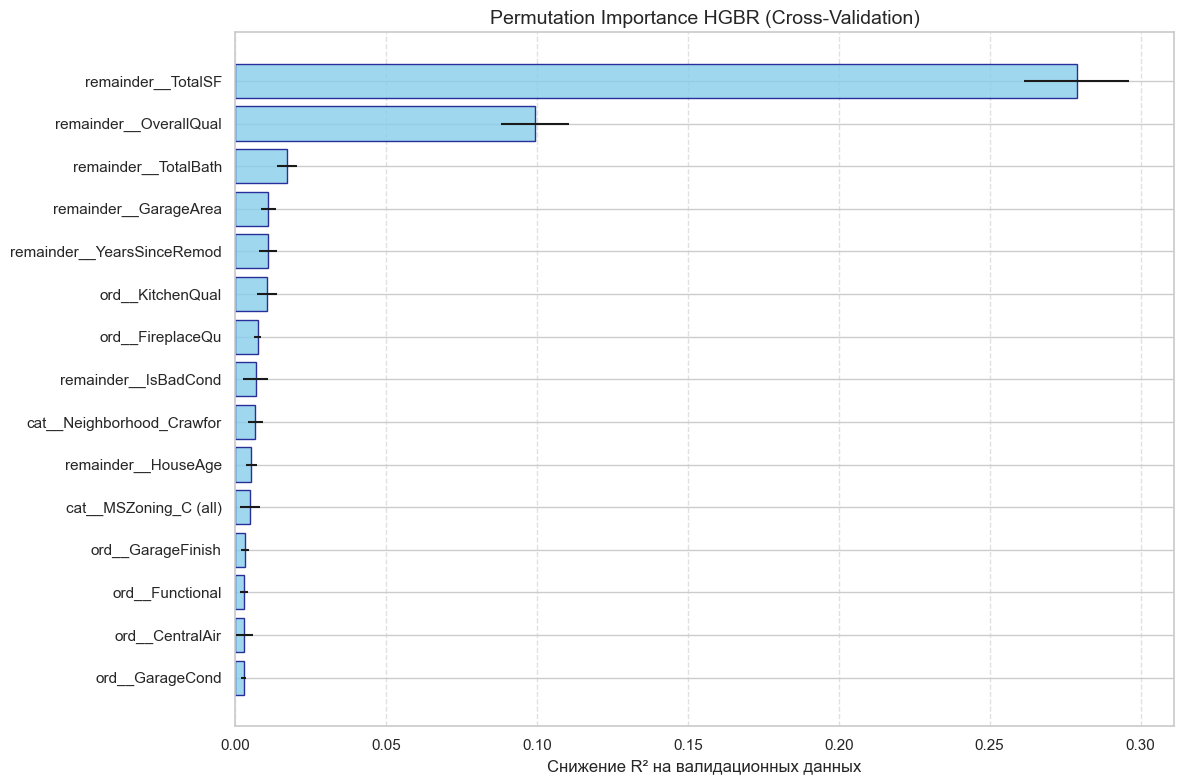

In [16]:
# 1. Считаем важность для HGBR тем же методом
mean_imp_hgb, std_imp_hgb = core.calculate_cv_permutation_importance(
    grid_search_hgbr.best_estimator_, X_prepared, y_train, cv
)

# 2. Упаковываем в DataFrame (для визуализации)
importance_df_hgb = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_imp_hgb,
    'std': std_imp_hgb
}).sort_values(by='importance', ascending=False).head(15)

# 3. Рисуем через универсальную функцию
viz.plot_permutation_importance(importance_df_hgb, model_name="HGBR", save_path=os.path.join(MODELING_FIGURES_DIR, 'permutation_importance_HGBR.png'))

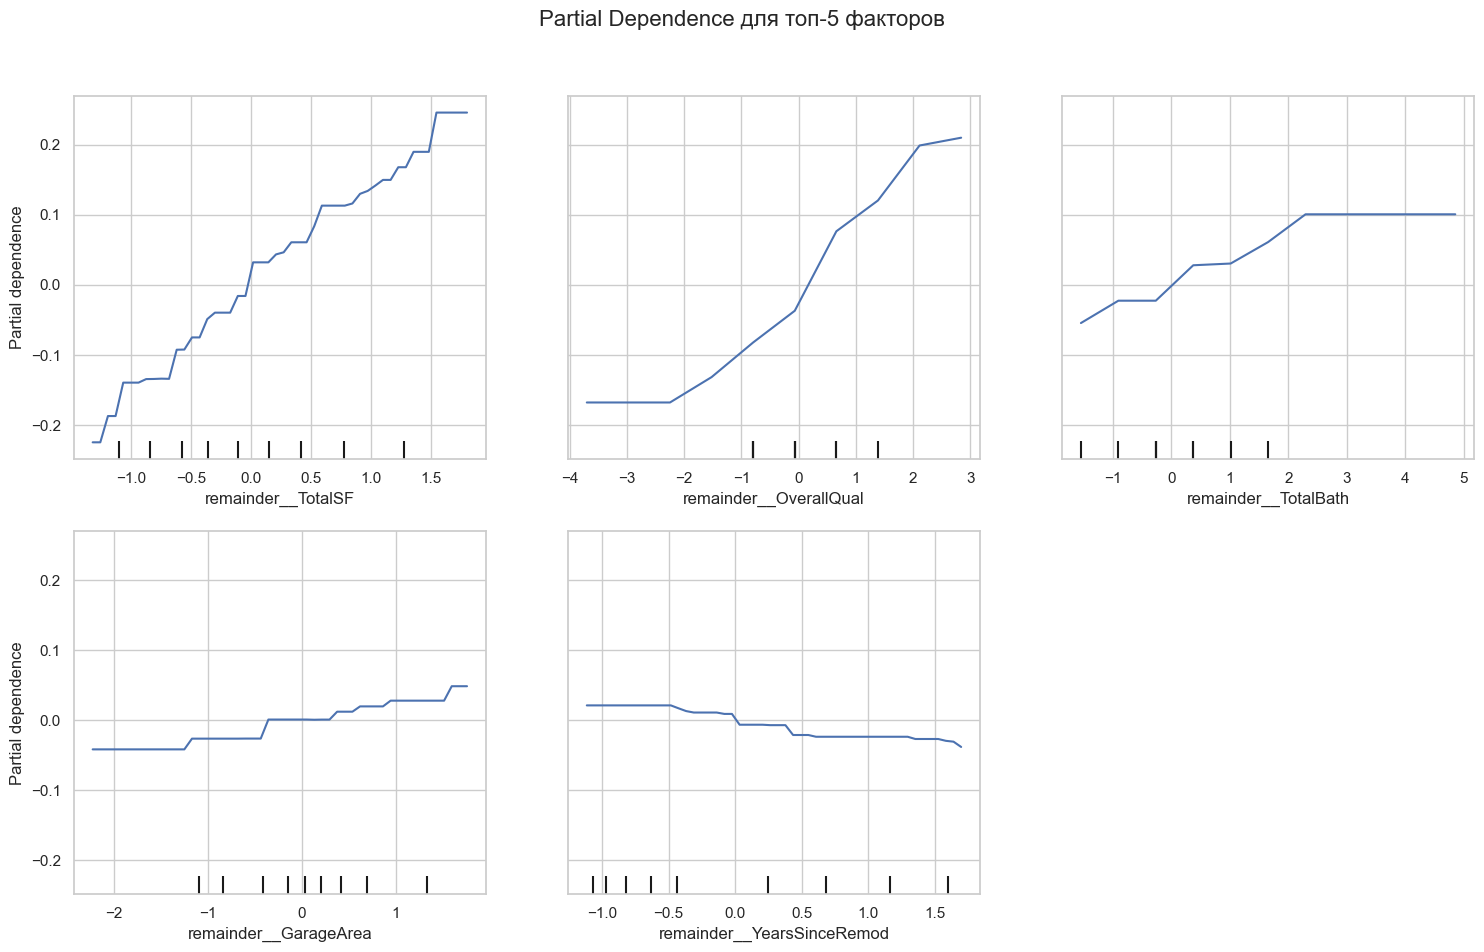

In [17]:
viz.plot_pdp_top_features(
    grid_search_hgbr.best_estimator_,           
    X_prepared,           
    feature_names,        
    importance_df_hgb,    
    top_n=5,
    save_path=os.path.join(MODELING_FIGURES_DIR, 'pdp_top_features.png')
)

In [31]:
estimators = [
    ('lasso', grid_search_lasso.best_estimator_),
    ('rf', grid_search_rf.best_estimator_),
    ('hgb', grid_search_hgbr.best_estimator_)
]


stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=cv, 
    n_jobs=-1,
)

final_model = get_pipeline(model=stacking_reg)

final_model.fit(X_train, y_train)

joblib.dump(final_model, os.path.join(MODELING_DIR,'final_production_model.joblib'))

['C:\\Users\\ggosh\\AI_Work\\MLtask\\MLtask\\project\\artifacts\\03_modeling_eval\\final_production_model.joblib']

In [32]:
stack_results = cross_validate(
    stacking_reg, 
    X_prepared, 
    y_train, 
    cv=cv, 
    scoring=scoring)

core.print_cv_results(stack_results, "Stacling")

--- РЕЗУЛЬТАТЫ Stacling ---
Честный RMSE на CV: 0.1168
Честный MSE на CV:  0.0136
Честный r2 на CV:   0.9143
Честный MAE на CV:  0.0815


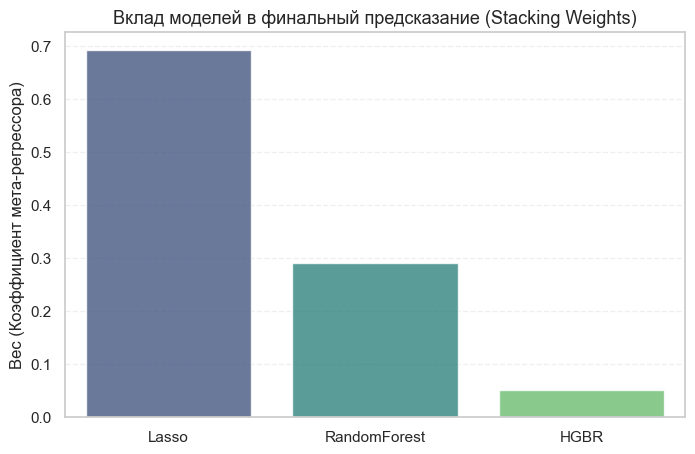

In [45]:
model_names = ['Lasso', 'RandomForest',  'HGBR']
viz.plot_stacking_weights(stacking_reg.final_estimator_.coef_, model_names, save_path=os.path.join(MODELING_FIGURES_DIR,'stacking_weights.png'))

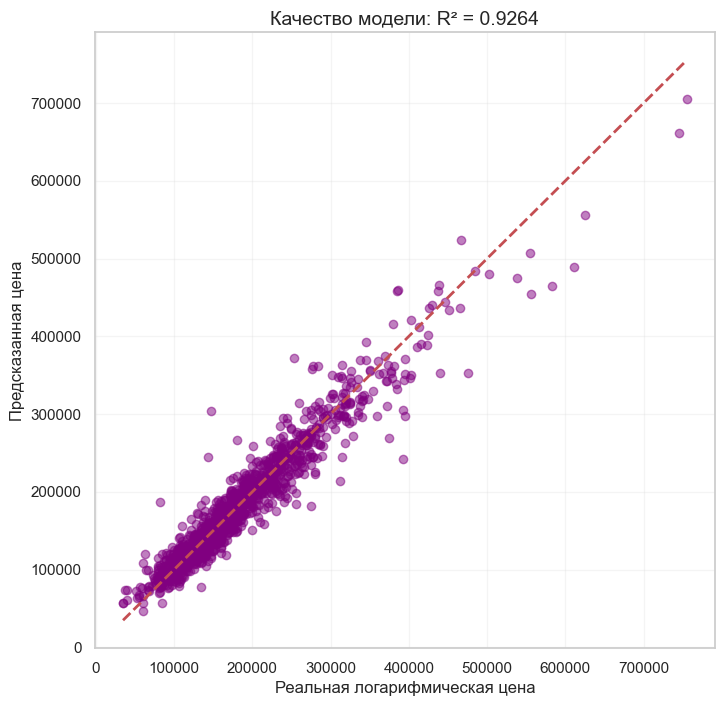

In [ ]:
y_pred_log = cross_val_predict(stacking_reg, X_prepared, y_train, cv=cv)

# 2. Возвращаем цены в реальный масштаб (доллары)
y_train_actual = np.expm1(y_train)
y_pred_actual = np.expm1(y_pred_log)

# 3. Считаем R² в реальном масштабе 
r2 = r2_score(y_train_actual, y_pred_actual)

# 4. Визуализация
viz.plot_actual_vs_predicted(
    y_train_actual, 
    y_pred_actual, 
    r2_score=r2, 
    save_path=os.path.join(MODELING_FIGURES_DIR, 'stacking_results.png')
)

In [38]:
# ИНФЕРЕНС: модель предсказывает логарифм цены
y_test_log_preds = stacking_reg.predict(test_prepared)

# Обратная трансформация (из логарифма в доллары)
y_test_final = np.expm1(y_test_log_preds)

# Формируем файл для отправки
submission = pd.DataFrame({
    "Id": test_raw["Id"],
    "SalePrice": y_test_final
})

path = os.path.join(MODELING_DIR, 'submission.csv')
submission.to_csv(path, index=False)

In [ ]:
# Создаем словарь с данными

results_data = {
    'Model': ['Stacking', 'Lasso', 'HistGradientBoosting', 'RandomForest', 'Baseline (Dummy)'],
    'R2':   [0.9143, 0.9126, 0.8996, 0.8907, -0.0007],
    'RMSE': [0.1168, 0.1179, 0.1265, 0.1320, 0.3996],
    'MAE':  [0.0815, 0.0823, 0.0887, 0.0904, 0.3102],
    'MSE':  [0.0136, 0.0139, 0.0160, 0.0174, 0.1597]
}
# Создаем DataFrame
df_results = pd.DataFrame(results_data)

path = os.path.join(MODELING_DIR, 'metrics_comparison.csv')
df_results.to_csv(path, index=False)

print(f"Таблица успешно сохранена в: {path}")

Таблица успешно сохранена в: C:\Users\ggosh\AI_Work\MLtask\MLtask\project\artifacts\03_modeling_eval\metrics_comparison.csv


In [ ]:
import json

best_meta_info = {
    "architecture": "StackingRegressor(Lasso, RF, HGBR -> Ridge)",
    "meta_model": "Ridge(alpha=1.0)",

    "base_models": {
        "lasso": grid_search_lasso.best_params_,
        "hgb": grid_search_hgbr.best_params_,
        "rf": grid_search_rf.best_params_,
    },
    
    "r2": 0.9143,
    "rmse": 0.1168,
    "mae": 0.0815,
    "mse": 0.0136
}

# Сохраняем в папку 03_modeling_eval
path = os.path.join(TRAIN_PARAMS_DIR, 'best_meta_model.json')
with open(path, "w", encoding='utf-8') as f:
    json.dump(best_meta_info, f, indent=4, ensure_ascii=False)

print(f"Паспорт модели сохранен! по пути {path}")

Паспорт модели сохранен! по пути C:\Users\ggosh\AI_Work\MLtask\MLtask\project\configs\best_meta_model.json


In [44]:
search_summaries = {
    "Baseline_dummy": {
        "strategy": "mean",
        "best_score_rmse": 0.3996,
        "best_score_mse": 0.1597,
        "best_score_mae": 0.3102,
        "best_score_r_2": -0.0007,
        "notes": "Нулевая точка отсчета. Показывает точность при простом угадывании среднего значения цен."
    },
    "Lasso": {
        "max_iter": 10000,
        "best_params": grid_search_lasso.best_params_,
        "best_score_rmse": 0.1179,
        "best_score_mse": 0.0139,
        "best_score_mae": 0.0823,
        "best_score_r_2": 0.9126,
        "notes": "Lasso занулила 168 признаков из 264."
    },
    "HistGradientBoostingRegressor": {
        "max_iter": 2000,
        "best_params": grid_search_hgbr.best_params_,
        "best_score_rmse": 0.1265,
        "best_score_mse": 0.0160,
        "best_score_mae": 0.0887,
        "best_score_r_2": 0.8996,
        "notes": f"Сходимость достигнута на {grid_search_hgbr.best_estimator_.n_iter_} итерации благодаря Early Stopping."
    },
    "RandomForest": {
        "best_params": grid_search_rf.best_params_,
        "best_score_rmse": 0.1320,
        "best_score_mse": 0.0174,
        "best_score_mae": 0.0904,
        "best_score_r_2": 0.8907,
        "notes": "Сходимость достигнута на уровне 300 деревьев."
    },
    "StackingRegressor": {
        "meta_model": "Ridge",
        "best_score_rmse": 0.1168,
        "best_score_mse": 0.0136,
        "best_score_mae": 0.0815,
        "best_score_r_2": 0.9143,
        "notes": "Финальный ансамбль: объединение сильных сторон Lasso и HGBR и RFRegressor через мета-модель Ridge."
    }
}
# Сохраняем
path_summary = os.path.join(MODELING_DIR, 'search_summaries.json')
with open(path_summary, "w", encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=4, ensure_ascii=False)

print(f"Сводка поисков сохранена в: {path_summary}")

Сводка поисков сохранена в: C:\Users\ggosh\AI_Work\MLtask\MLtask\project\artifacts\03_modeling_eval\search_summaries.json
